# 予測・提出ファイル生成（predicting）

このNotebookでやること：

1. 学習済みモデル・前処理済みデータの読み込み
2. testデータの予測
3. 予測値の確認
4. 提出ファイルの生成

**入力ファイル（`models/` フォルダ）**

| ファイル | 内容 |
|---|---|
| `models/model.pkl` | 学習済みRidgeモデル |
| `models/X_test.npy` | 前処理済みtest特徴量 |
| `models/y_train.npy` | log変換済みtrain目的変数（分布確認用） |
| `models/test_sample_numbers.npy` | testのsample_number |

**出力ファイル**

| ファイル | 内容 |
|---|---|
| `submission.csv` | SIGNATEへの提出ファイル |

## 1. ライブラリの読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 2. 学習済みモデル・データの読み込み

In [2]:
model       = joblib.load('models/model.pkl')
X_test      = np.load('models/X_test.npy')
y_train_log = np.load('models/y_train.npy')
test_ids    = np.load('models/test_sample_numbers.npy')

print(f'モデル    : {type(model).__name__}  alpha={model.alpha}')
print(f'X_test    : {X_test.shape}')
print(f'test_ids  : {test_ids.shape}  先頭3={test_ids[:3]}  末尾3={test_ids[-3:]}')

モデル    : Ridge  alpha=2000
X_test    : (550, 20)
test_ids  : (550,)  先頭3=[95 96 97]  末尾3=[1819 1820 1821]


## 3. 予測の実行

モデルは `log(1 + 含水率)` スケールで学習しているため、予測後に `expm1`（= exp(x) - 1）で元のスケールに戻します。

In [3]:
# log スケールで予測
y_pred_log = model.predict(X_test)

# 元のスケール（含水率 %）に変換
y_pred = np.expm1(y_pred_log)

print(f'予測値の統計（含水率 %）')
print(f'  min   : {y_pred.min():.2f}')
print(f'  mean  : {y_pred.mean():.2f}')
print(f'  median: {np.median(y_pred):.2f}')
print(f'  max   : {y_pred.max():.2f}')
print()

# 負の予測値チェック（含水率は0以上のはず）
n_negative = (y_pred < 0).sum()
if n_negative > 0:
    print(f'警告: 負の予測値が {n_negative} 件あります。クリッピングを検討してください。')
    y_pred = np.clip(y_pred, 0, None)  # 0未満をカット
    print('→ 0にクリッピングしました。')
else:
    print('負の予測値: なし（正常）')

予測値の統計（含水率 %）
  min   : 9.83
  mean  : 36.65
  median: 19.21
  max   : 149.93

負の予測値: なし（正常）


## 4. 予測値の分布確認

trainの実測値と予測値の分布を比較して、大きなズレがないかを確認します。
分布が極端にかけ離れている場合は前処理やモデルに問題がある可能性があります。

/tmp/ipykernel_344841/3184805227.py:17: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_344841/3184805227.py:17: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_344841/3184805227.py:17: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_344841/3184805227.py:17: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_344841/3184805227.py:17: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_344841/3184805227.py:17: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_344841/3184805227.py:17: UserWarning: Glyph 28204 (\N{CJK UNIFIED I

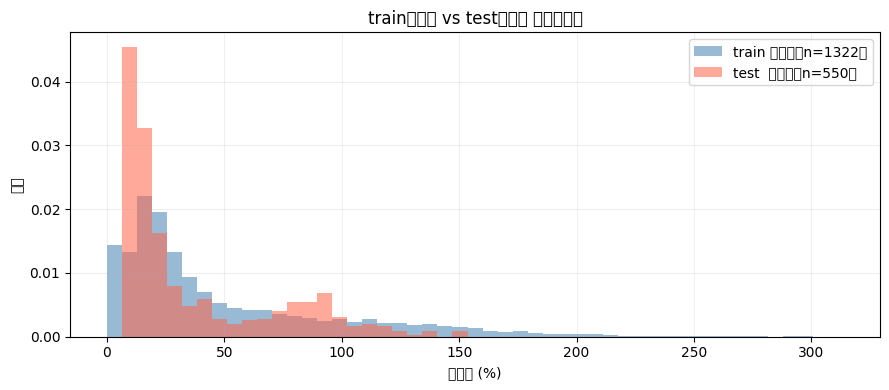

分布の中央値比較
  train実測値: 29.05%
  test予測値 : 19.21%


In [4]:
y_train_orig = np.expm1(y_train_log)

fig, ax = plt.subplots(figsize=(9, 4))

bins = np.linspace(0, max(y_train_orig.max(), y_pred.max()) * 1.05, 50)

ax.hist(y_train_orig, bins=bins, alpha=0.55, color='steelblue',
        label=f'train 実測値（n={len(y_train_orig)}）', density=True)
ax.hist(y_pred,       bins=bins, alpha=0.55, color='tomato',
        label=f'test  予測値（n={len(y_pred)}）',  density=True)

ax.set_xlabel('含水率 (%)')
ax.set_ylabel('密度')
ax.set_title('train実測値 vs test予測値 の分布比較')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('分布の中央値比較')
print(f'  train実測値: {np.median(y_train_orig):.2f}%')
print(f'  test予測値 : {np.median(y_pred):.2f}%')

## 5. 提出ファイルの生成

提出フォーマットの仕様：
- ヘッダーなし
- 1列目：`sample_number`
- 2列目：予測した含水率（%）
- 行数：550行（testの全サンプル）

In [5]:
submission = pd.DataFrame({
    'sample_number'   : test_ids,
    'moisture_content': y_pred,
})

# ヘッダーなし・インデックスなしで保存
submission.to_csv('submission.csv', index=False, header=False)

print('提出ファイル生成完了: submission.csv')
print(f'行数: {len(submission)}  （期待値: 550）')
print()
print('先頭5行:')
print(submission.head().to_string(index=False))
print('...')
print('末尾3行:')
print(submission.tail(3).to_string(index=False))

提出ファイル生成完了: submission.csv
行数: 550  （期待値: 550）

先頭5行:
 sample_number  moisture_content
            95        149.868193
            96        100.899007
            97        102.524891
            98        112.051444
            99        120.424442
...
末尾3行:
 sample_number  moisture_content
          1819         14.047327
          1820         13.838074
          1821         13.605942


In [7]:
# フォーマット最終確認（sample_submitと並べて比較）
sample_sub = pd.read_csv('../data/sample_submit.csv', encoding='shift-jis', header=None)
my_sub     = pd.read_csv('submission.csv', header=None)

print('=== フォーマット確認 ===')
print(f'sample_submit 行数: {len(sample_sub)}  列数: {sample_sub.shape[1]}')
print(f'自分の提出    行数: {len(my_sub)}  列数: {my_sub.shape[1]}')
print()
print('sample_number の一致確認:', (sample_sub[0].values == my_sub[0].values).all())
print()
print('sample_submitの先頭3行（参考）:')
print(sample_sub.head(3).to_string(index=False, header=False))
print()
print('自分の提出の先頭3行:')
print(my_sub.head(3).to_string(index=False, header=False))

=== フォーマット確認 ===
sample_submit 行数: 550  列数: 2
自分の提出    行数: 550  列数: 2

sample_number の一致確認: True

sample_submitの先頭3行（参考）:
95 50
96 50
97 50

自分の提出の先頭3行:
95 149.868193
96 100.899007
97 102.524891
